# Exploration of SBM way

In [20]:
import networkx as nx
import matplotlib.pyplot as plt
import torch
import time
import random
import json
from tqdm import tqdm
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from networkx.generators.community import stochastic_block_model, LFR_benchmark_graph
from torch_geometric.utils import from_networkx, dropout_adj, to_networkx, to_undirected

import src.encoder as enc
import src.decoder as dec
import src.utils as ut
import src.train_utils as tr
import src.contrastive_pretrain as pretr
import src.contrastive_model as ctmod
from src.contrastive_augmentation import drop_feature, cav, ced, community_detection, community_strength, transition, get_edge_weight

hp = {
    'xdp': 0.7,
    'tdp': 0.3,
    'pt': 0.75,
    'gnnedp': 0.0,
    'preedp': 0.4,
    'predp': 0.05,
    'gnndp': 0.05,
    'res': False,
    'probscale': 4.3,
    'proboffset': 2.8,
    'alpha': 1.0,
    'gnnlr': 0.0043,
    'prelr': 0.0024,
    'batch_size': 1152,
    'ln': True,
    'lnnn': True,
    'epochs': 100,
    'model': 'puregcn',
    'runs': 10,
    'hiddim': 256,
    'mplayers': 1,
    'testbs': 8192,
    'maskinput': True,
    'jk': True,
    'use_xlin': True,
    'tailact': True,
    'use_valedges_as_input': False,
    'freeze': True,
    'inner': True,
    'ct_param': {
    	'learning_rate': 0.01,
    	'num_hidden': 256,
    	'num_proj_hidden': 32,
    	'activation': 'prelu',
    	'base_model': 'GCNConv',
    	'num_layers': 2,
    	'drop_edge_rate_1': 0.3,
    	'drop_edge_rate_2': 0.4,
    	'drop_feature_rate_1': 0.1,
    	'drop_feature_rate_2': 0.0,
    	'tau': 0.4,
    	'num_epochs': 500,
    	'weight_decay': 1e-5,
    	'drop_scheme': 'degree',
    }
}
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

Data(edge_index=[2, 3544], community=[5], num_nodes=400, probs=[5, 5], sizes=[5], num_features=400, x=[400, 400])

[[1.1381e-01 1.3000e-04 1.6000e-04 2.5000e-04 2.2000e-04]
 [1.3000e-04 1.1228e-01 8.0000e-05 3.0000e-04 4.0000e-05]
 [1.6000e-04 8.0000e-05 9.8770e-02 1.6000e-04 1.4000e-04]
 [2.5000e-04 3.0000e-04 1.6000e-04 1.1996e-01 1.5000e-04]
 [2.2000e-04 4.0000e-05 1.4000e-04 1.5000e-04 1.0393e-01]]


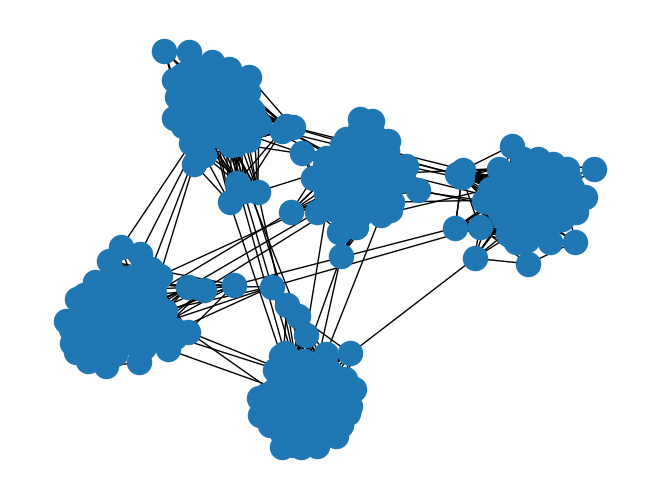

In [21]:
def LFR_gen():
    G = LFR_benchmark_graph(400, 4, 2, 0.05, average_degree=10, min_community=75, seed=10)
    G.remove_edges_from(nx.selfloop_edges(G)) # remove self loops
    data = from_networkx(G)
    data.edge_index = to_undirected(data.edge_index)
    communities = {frozenset(G.nodes[v]["community"]) for v in G}
    probs = np.zeros((len(communities), len(communities)))
    sizes = []
    for idx, c in enumerate(communities):
        sizes.append(len(c))
        for n in c:
            G.nodes[n]["com"] = idx # get com label
    for u, v in zip(data.edge_index[0], data.edge_index[1]): # count number of edge per com
        u = float(u)
        v = float(v)
        probs[G.nodes[u]["com"], G.nodes[v]["com"]] += 1
    for x in range(len(probs)): # make the probs
        for y in range(len(probs)):
            if x == y:
                probs[x,x] /= (sizes[x]*(sizes[x]-1))/2
            else:
                probs[x,y] /= ((sizes[x]+sizes[y])*(sizes[x]+sizes[y]-1))/2
    probs /= 2 # undirected graph
    data.community = communities
    data.probs = probs
    data.sizes = sizes
    data.num_features = data.num_nodes
    data.x = F.one_hot(torch.arange(0, data.num_nodes)).float()
    if device is not None:
        data = data.to(device)
    display(data)
    print(np.round(probs, 5))
    nx.draw(G)
    return data
data = LFR_gen()

10 split from the dataset [Data(edge_index=[2, 3616], block=[400], partition=[5], name='stochastic_block_model', num_nodes=400, sizes=[5], probs=[5, 5], num_features=400, x=[400, 400])]


100%|██████████| 10/10 [00:00<00:00, 86.61it/s]

split time:  0.12  s
dataset split 
train edge 1267
valid edge 180
valid edge_neg 180
test edge 361
test edge_neg 361


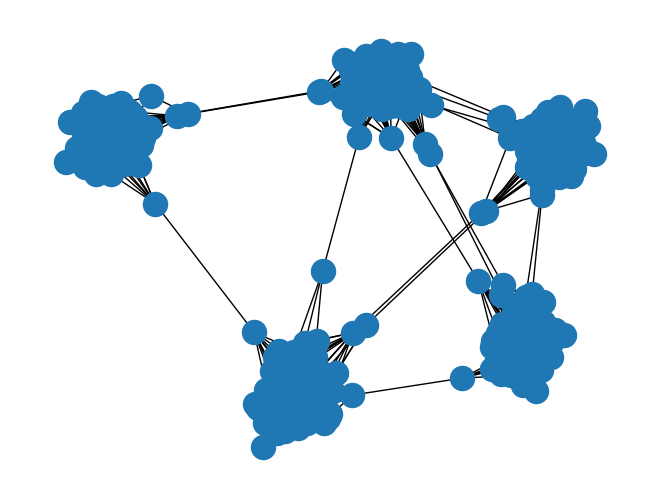

In [22]:
# generator of graph
def gen_sbm(sizes, probs, device=None, seed=random.randint(1, 10000), draw=False):
    G = stochastic_block_model(sizes, probs, seed=seed)
    G.remove_edges_from(nx.selfloop_edges(G)) # remove self loops
    if draw:
        nx.draw(G)
    #plt.savefig(f'{random.randint(0, 10000)}sbm.png')
    data = from_networkx(G)
    data.num_nodes = sum(sizes)
    data.sizes = sizes
    data.probs = probs
    data.num_features = data.num_nodes
    data.x = F.one_hot(torch.arange(0, sum(sizes))).float()
    if device is not None:
        data = data.to(device)
    return data
data = gen_sbm(data.sizes, data.probs, device, 0, True)

evaluator = ut.get_evaluator()
data_split = ut.DataSplit([data], device, 10)

In [23]:
class perfect_pred:
    def __init__(self, probs, block):
        super().__init__()
        self.probs = probs
        self.block = block

    def __call__(self, u, v):
        b1 = self.block[u]
        b2 = self.block[v]
        return torch.tensor(self.probs[b1][b2]).unsqueeze(0)

test_res = []
res_dict = {"Hits@10": [], "Hits@20": [], "Hits@50": [], "Hits@100": [], 'ROCAUC': []}
for r in range(hp['runs']):
    data, split_edge = data_split.get(r)
    predictor = perfect_pred(data.probs, data.block)
    def test_split(split):
        # pred positive edges and negatives edges for nodes in the split
        pos_test_edge = split_edge[split]['edge'].to(device)
        neg_test_edge = split_edge[split]['edge_neg'].to(device)
        pos_test_preds = []
        for perm in DataLoader(range(pos_test_edge.size(0)), 1):
            edge = pos_test_edge[perm].t()
            out = predictor(edge[0], edge[1])
            pos_test_preds += [out.cpu()]
        pos_test_pred = torch.cat(pos_test_preds, dim=0)
        neg_test_preds = []
        for perm in DataLoader(range(neg_test_edge.size(0)), 1):
            edge = neg_test_edge[perm].t()
            out = predictor(edge[0], edge[1])
            neg_test_preds += [out.cpu()]
        neg_test_pred = torch.cat(neg_test_preds, dim=0)
    
        return pos_test_pred, neg_test_pred
    
    pos_valid_pred, neg_valid_pred = test_split('valid')
    pos_test_pred, neg_test_pred = test_split('test')
    
    results = {}
    evaluator.eval_metric = 'hits@k'
    for K in [10, 20, 50, 100]:
        evaluator.K = K
        valid_hits = evaluator.eval({
            'y_pred_pos': pos_valid_pred,
            'y_pred_neg': neg_valid_pred,
        })[f'hits@{K}']
        test_hits = evaluator.eval({
            'y_pred_pos': pos_test_pred,
            'y_pred_neg': neg_test_pred,
        })[f'hits@{K}']
        results[f'Hits@{K}'] = (valid_hits, test_hits)
    pos_valid_pred = pos_valid_pred[:neg_valid_pred.shape[0]]
    pos_test_pred = pos_test_pred[:neg_test_pred.shape[0]]
    evaluator.eval_metric = 'rocauc'
    valid_auc = evaluator.eval({
        'y_pred_pos': pos_valid_pred,
        'y_pred_neg': neg_valid_pred,
    })['rocauc']
    test_auc = evaluator.eval({
        'y_pred_pos': pos_test_pred,
        'y_pred_neg': neg_test_pred,
    })['rocauc']
    results['ROCAUC'] = (valid_auc, test_auc)
    for key, result in results.items():
        valid_hits, test_hits = result
        res_dict[key].append(test_hits)
res_dict, res_latex = ut.compute_table(res_dict, 'perfect pred')

print(res_dict)

    metrics    perfect pred
0   Hits@10   9.45$\pm$9.46
1   Hits@20  25.29$\pm$8.16
2   Hits@50  69.2$\pm$11.63
3  Hits@100  99.09$\pm$0.41
4    ROCAUC  91.09$\pm$1.17


In [24]:
def pretrain_grace_commu(model, data, param):
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=param['learning_rate'],
        weight_decay=param['weight_decay']
    )
    t1 = time.time()
    loss_res = []
    for epoch in tqdm(range(1, param['num_epochs'] + 1)):
        model.train()
        optimizer.zero_grad()
        data_sbm1 = gen_sbm(data.sizes, data.probs, data.x.device, epoch)
        data_sbm2 = gen_sbm(data.sizes, data.probs, data.x.device, epoch)
        # edge_index_1 = dropout_adj(data_sbm.edge_index, p=param[f'drop_edge_rate_{1}'])[0]
        # edge_index_2 = dropout_adj(data_sbm.edge_index, p=param[f'drop_edge_rate_{2}'])[0]
        # x_1 = drop_feature(data_sbm.x, param['drop_feature_rate_1'])
        # x_2 = drop_feature(data_sbm.x, param['drop_feature_rate_2'])
        z1 = model(data_sbm1.x, data_sbm1.edge_index)
        z2 = model(data_sbm2.x, data_sbm2.edge_index)
        loss = model.loss(z1, z2)
        loss.backward()
        optimizer.step()
        if epoch % 100 == 0:
            loss_res.append(round(float(loss), 2))
    print('pretrain loss: ', loss_res)
    pre_time = time.time()-t1
    print(f"pretrain time: {pre_time:.2f} s")
    return pre_time

def pretrain_bgrl_commu(model, data, param):
    optimizer = torch.optim.AdamW(model.trainable_parameters(), lr=param['learning_rate'], weight_decay=param['weight_decay'])

    lr_scheduler = ut.CosineDecayScheduler(param['learning_rate'], 1000, param['num_epochs'])
    mm_scheduler = ut.CosineDecayScheduler(1 - 0.99, 0, param['num_epochs'])

    t1 = time.time()
    loss_res = []
    for epoch in tqdm(range(1, param['num_epochs'] + 1)):
        model.train()

        lr = lr_scheduler.get(epoch)
        mm = 1 - mm_scheduler.get(epoch)

        optimizer.zero_grad()
        data_sbm = gen_sbm(data.sizes, data.probs, data.x.device)

        data_c1 = gen_sbm(data.sizes, data.probs, data.x.device, epoch)
        data_c2 = gen_sbm(data.sizes, data.probs, data.x.device, epoch)
        # data_c1.edge_index = dropout_adj(data_sbm.edge_index, p=param[f'drop_edge_rate_{1}'])[0]
        # data_c2.edge_index = dropout_adj(data_sbm.edge_index, p=param[f'drop_edge_rate_{2}'])[0]

        # data_c1.x = drop_feature(data_sbm.x, param['drop_feature_rate_1'])
        # data_c2.x = drop_feature(data_sbm.x, param['drop_feature_rate_2'])

        z1, y2 = model.train_forward(data_c1, data_c2)
        z2, y1 = model.train_forward(data_c2, data_c1)

        loss = 2 - F.cosine_similarity(z1, y2.detach(), dim=-1).mean() - F.cosine_similarity(z2, y1.detach(), dim=-1).mean() # loss simple
        loss.backward()
        optimizer.step()
        model.update_target_network(mm)

        if epoch % 100 == 0:
            loss_res.append(round(float(loss), 2))
    print('pretrain loss: ', loss_res)
    pre_time = time.time()-t1
    print(f"pretrain time: {pre_time:.2f} s")
    return pre_time

def pretrain_csgcl_commu(model, data, param):
    optimizer = torch.optim.Adam(model.parameters(),
                                 lr=param['learning_rate'],
                                 weight_decay=param['weight_decay'])
    t1 = time.time()
    loss_res = []
    for epoch in tqdm(range(1, param['num_epochs'] + 1)):
        model.train()
        optimizer.zero_grad()
        data_sbm1 = gen_sbm(data.sizes, data.probs, data.x.device)
        data_sbm2 = gen_sbm(data.sizes, data.probs, data.x.device)
        g = to_networkx(data_sbm1, to_undirected=True)
        communities = community_detection('leiden')(g).communities
        # com = transition(communities, g.number_of_nodes())
        com_cs, node_cs = community_strength(g, communities)
        # edge_weight = get_edge_weight(data_sbm.edge_index, com, com_cs)
        # edge_index_1 = ced(data_sbm.edge_index, edge_weight, p=param['drop_edge_rate_1'])
        # edge_index_2 = ced(data_sbm.edge_index, edge_weight, p=param['drop_edge_rate_2'])
        # x1 = cav(data_sbm.x, node_cs, param["drop_feature_rate_1"])
        # x2 = cav(data_sbm.x, node_cs, param['drop_feature_rate_2'])
        z1 = model(data_sbm1.x, data_sbm1.edge_index)
        z2 = model(data_sbm2.x, data_sbm2.edge_index)
        loss = model.team_up_loss(z1, z2,
                                  cs=node_cs,
                                  current_ep=epoch)
        loss.backward()
        optimizer.step()
        if epoch % 100 == 0:
            loss_res.append(round(float(loss), 2))
    print('pretrain loss: ', loss_res, ' s')
    pre_time = time.time()-t1
    print(f"pretrain time: {pre_time:.2f} s")
    return pre_time

In [25]:
full_res = []
def init_model(data, hp):
    _encoder = enc.ENCODER_GRACE(data.num_features, hp['ct_param']['num_hidden'], nn.Identity()).to(device)
    encoder = ctmod.GRACE(_encoder, hp['ct_param']['num_hidden'], hp['ct_param']['num_proj_hidden']).to(device)
    predictor = dec.inner_prod().to(device)
    return encoder, predictor
full_res.append(tr.runs('SBM_GRACE+Inner', init_model, pretrain_grace_commu, data_split, evaluator, hp))


def init_model(data, hp):
    _encoder = enc.ENCODER_BGRL([data.num_features, hp['ct_param']['num_hidden']], batchnorm=True).to(device)
    _predictor = ut.MLP_Head_BGRL(hp['ct_param']['num_hidden'], hp['ct_param']['num_hidden']).to(device)
    encoder = ctmod.BGRL(_encoder, _predictor).to(device)
    predictor = dec.inner_prod().to(device)
    return encoder, predictor
full_res.append(tr.runs('SBM_BGRL+Inner', init_model, pretrain_bgrl_commu, data_split, evaluator, hp))


def init_model(data, hp):
    _encoder = enc.ENCODER_GRACE(data.num_features, hp['ct_param']['num_hidden'], nn.Identity()).to(device)
    encoder = ctmod.CSGCL(_encoder,
                      hp['ct_param']['num_hidden'],
                      hp['ct_param']['num_proj_hidden'],
                      hp['ct_param']['tau']).to(device)
    predictor = dec.inner_prod().to(device)
    return encoder, predictor
full_res.append(tr.runs('SBM_CSGCL+inner', init_model, pretrain_csgcl_commu, data_split, evaluator, hp))

def init_model(data, hp):
    encoder = enc.ENCODER_NCN(data.num_features, hp['hiddim'], hp['hiddim'], hp['mplayers'],
                    hp['gnndp'], hp['ln'], hp['res'], data.max_x,
                    hp['model'], edrop=hp['gnnedp'],  xdropout=hp['xdp'], taildropout=hp['tdp']).to(device)
    predictor = dec.inner_prod().to(device)
    return encoder, predictor
full_res.append(tr.runs('GCN+inner', init_model, None, data_split, evaluator, hp))


def init_model(data, hp):
    _encoder = enc.ENCODER_GRACE(data.num_features, hp['ct_param']['num_hidden'], nn.Identity()).to(device)
    encoder = ctmod.GRACE(_encoder, hp['ct_param']['num_hidden'], hp['ct_param']['num_proj_hidden']).to(device)
    predictor = dec.inner_prod().to(device)
    return encoder, predictor
full_res.append(tr.runs('GRACE+inner', init_model, pretr.pretrain_grace, data_split, evaluator, hp))


hp['ct_param']['drop_scheme'] = 'degree'
def init_model(data, hp):
    _encoder = enc.ENCODER_GRACE(data.num_features, hp['ct_param']['num_hidden'], nn.Identity()).to(device)
    encoder = ctmod.GRACE(_encoder, hp['ct_param']['num_hidden'], hp['ct_param']['num_proj_hidden']).to(device)
    predictor = dec.inner_prod().to(device)
    return encoder, predictor
full_res.append(tr.runs('GCA_deg+inner', init_model, pretr.pretrain_gca, data_split, evaluator, hp))


hp['ct_param']['drop_scheme'] = 'pr'
def init_model(data, hp):
    _encoder = enc.ENCODER_GRACE(data.num_features, hp['ct_param']['num_hidden'], nn.Identity()).to(device)
    encoder = ctmod.GRACE(_encoder, hp['ct_param']['num_hidden'], hp['ct_param']['num_proj_hidden']).to(device)
    predictor = dec.inner_prod().to(device)
    return encoder, predictor
full_res.append(tr.runs('GCA_pr+inner', init_model, pretr.pretrain_gca, data_split, evaluator, hp))


hp['ct_param']['drop_scheme'] = 'evc'
def init_model(data, hp):
    _encoder = enc.ENCODER_GRACE(data.num_features, hp['ct_param']['num_hidden'], nn.Identity()).to(device)
    encoder = ctmod.GRACE(_encoder, hp['ct_param']['num_hidden'], hp['ct_param']['num_proj_hidden']).to(device)
    predictor = dec.inner_prod().to(device)
    return encoder, predictor
full_res.append(tr.runs('GCA_evc+inner', init_model, pretr.pretrain_gca, data_split, evaluator, hp))


def init_model(data, hp):
    _encoder = enc.ENCODER_BGRL([data.num_features, hp['ct_param']['num_hidden']], batchnorm=True).to(device)
    _predictor = ut.MLP_Head_BGRL(hp['ct_param']['num_hidden'], hp['ct_param']['num_hidden']).to(device)
    encoder = ctmod.BGRL(_encoder, _predictor).to(device)
    predictor = dec.inner_prod().to(device)
    return encoder, predictor
full_res.append(tr.runs('BGRL+inner', init_model, pretr.pretrain_bgrl, data_split, evaluator, hp))


hp['ct_param']['drop_scheme'] = 'degree'
def init_model(data, hp):
    _encoder = enc.ENCODER_BGRL([data.num_features, hp['ct_param']['num_hidden']], batchnorm=True).to(device)
    _predictor = ut.MLP_Head_BGRL(hp['ct_param']['num_hidden'], hp['ct_param']['num_hidden']).to(device)
    encoder = ctmod.BGRL(_encoder, _predictor).to(device)
    predictor = dec.inner_prod().to(device)
    return encoder, predictor
full_res.append(tr.runs('BGRL_deg+inner', init_model, pretr.pretrain_bgrl_adaptative, data_split, evaluator, hp))


hp['ct_param']['drop_scheme'] = 'pr'
def init_model(data, hp):
    _encoder = enc.ENCODER_BGRL([data.num_features, hp['ct_param']['num_hidden']], batchnorm=True).to(device)
    _predictor = ut.MLP_Head_BGRL(hp['ct_param']['num_hidden'], hp['ct_param']['num_hidden']).to(device)
    encoder = ctmod.BGRL(_encoder, _predictor).to(device)
    predictor = dec.inner_prod().to(device)
    return encoder, predictor
full_res.append(tr.runs('BGRL_pr+inner', init_model, pretr.pretrain_bgrl_adaptative, data_split, evaluator, hp))


hp['ct_param']['drop_scheme'] = 'evc'
def init_model(data, hp):
    _encoder = enc.ENCODER_BGRL([data.num_features, hp['ct_param']['num_hidden']], batchnorm=True).to(device)
    _predictor = ut.MLP_Head_BGRL(hp['ct_param']['num_hidden'], hp['ct_param']['num_hidden']).to(device)
    encoder = ctmod.BGRL(_encoder, _predictor).to(device)
    predictor = dec.inner_prod().to(device)
    return encoder, predictor
full_res.append(tr.runs('BGRL_evc+inner', init_model, pretr.pretrain_bgrl_adaptative, data_split, evaluator, hp))


def init_model(data, hp):
    _encoder = enc.ENCODER_GRACE(data.num_features, hp['ct_param']['num_hidden'], nn.Identity()).to(device)
    encoder = ctmod.CSGCL(_encoder,
                      hp['ct_param']['num_hidden'],
                      hp['ct_param']['num_proj_hidden'],
                      hp['ct_param']['tau']).to(device)
    predictor = dec.inner_prod().to(device)
    return encoder, predictor
full_res.append(tr.runs('CSGCL+inner', init_model, pretr.pretrain_csgcl, data_split, evaluator, hp))


def init_model(data, hp):
    _encoder = enc.ENCODER_BGRL([data.num_features, hp['ct_param']['num_hidden']], batchnorm=True).to(device)
    _predictor = ut.MLP_Head_BGRL(hp['ct_param']['num_hidden'], hp['ct_param']['num_hidden']).to(device)
    encoder = ctmod.BGRL(_encoder, _predictor).to(device)
    predictor = dec.inner_prod().to(device)
    return encoder, predictor
full_res.append(tr.runs('BGRL_cs+inner', init_model, pretr.pretrain_bgrl_cs, data_split, evaluator, hp))


df, tex = ut.full_output(full_res)
df.to_csv(f'output/SBM_inner_400_res.csv', sep=';')

### SBM_GRACE+Inner ###


100%|██████████| 500/500 [01:39<00:00,  5.03it/s]

pretrain loss:  [5.27, 5.0, 4.89, 4.82, 4.81]
pretrain time: 99.50 s
test time 0.02 s
Run: 01, Epoch: 00, 
Hits@10: Valid: 11.67%, Test: 9.14%
Hits@20: Valid: 22.78%, Test: 11.91%
Hits@50: Valid: 45.00%, Test: 21.33%
Hits@100: Valid: 83.33%, Test: 47.92%
ROCAUC: Valid: 68.02%, Test: 66.26%
---



 72%|███████▏  | 360/500 [01:12<00:28,  5.00it/s]


KeyboardInterrupt: 